First 5 Rows:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage:

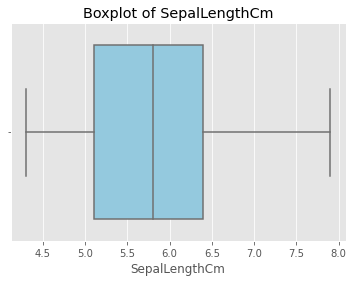

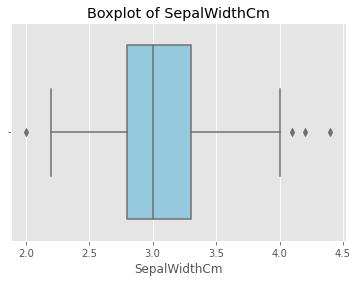

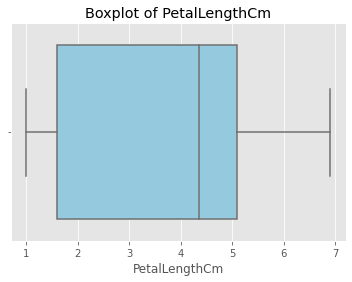

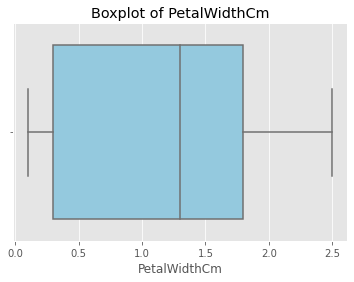

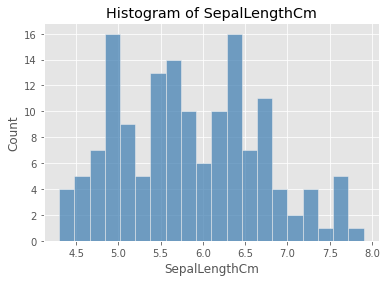

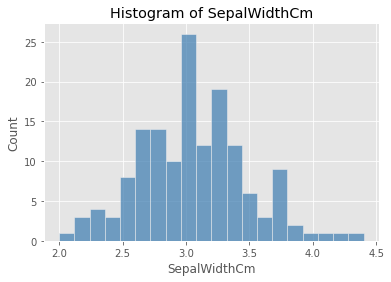

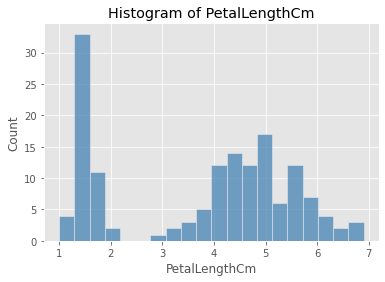

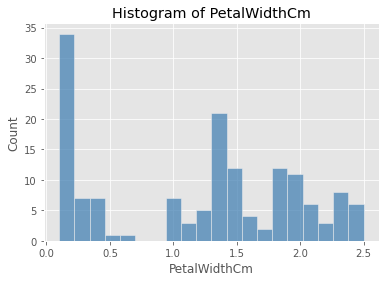

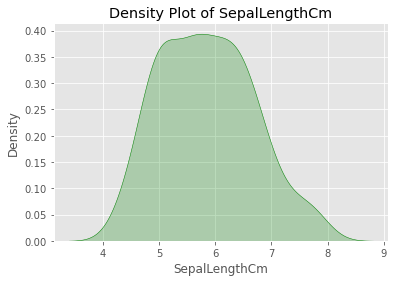

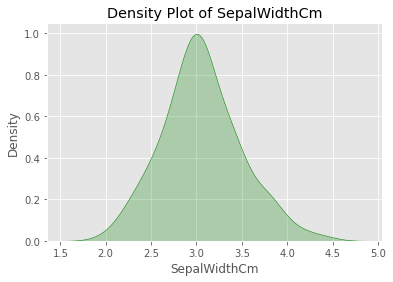

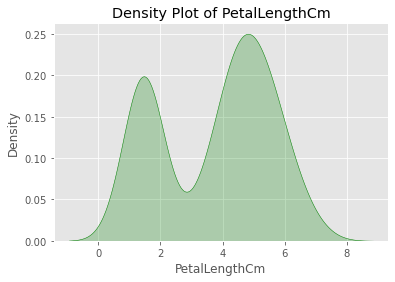

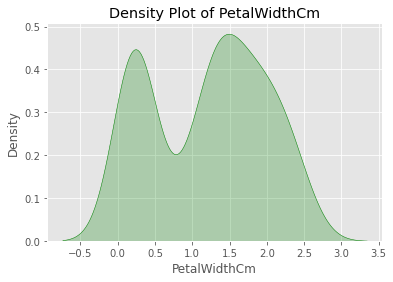

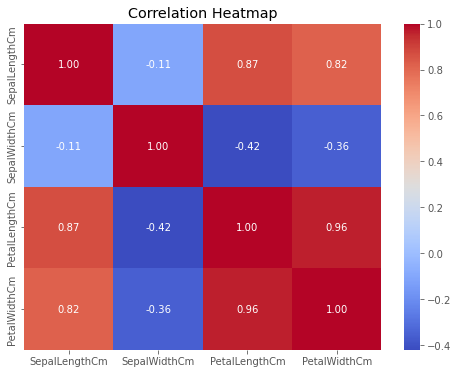

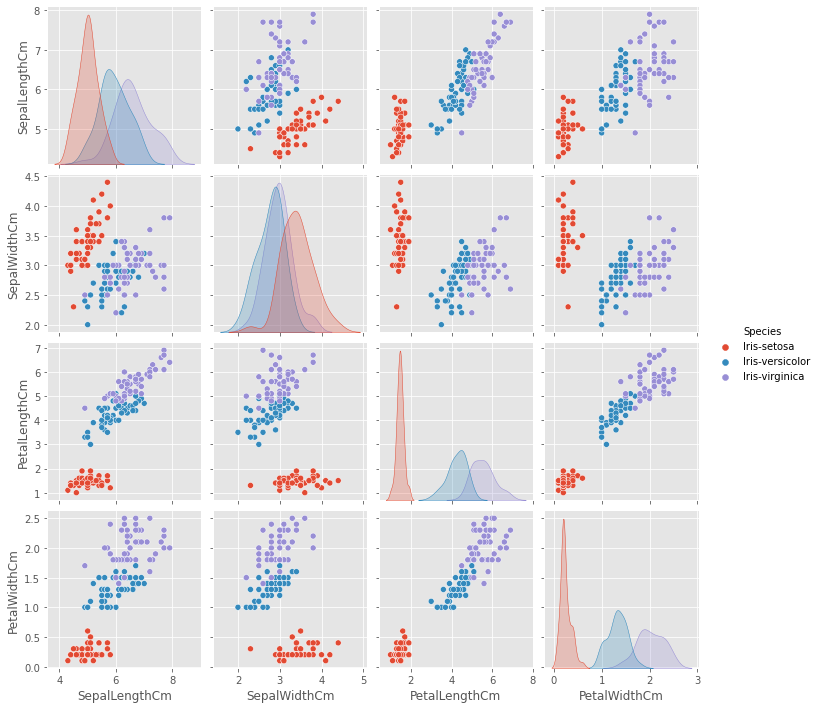

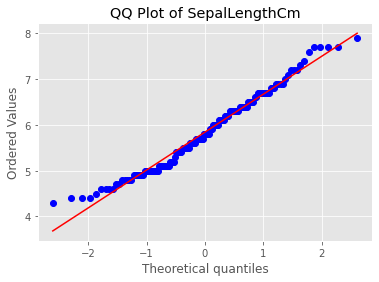

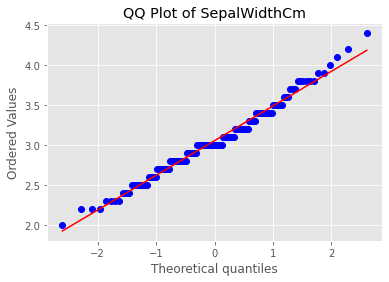

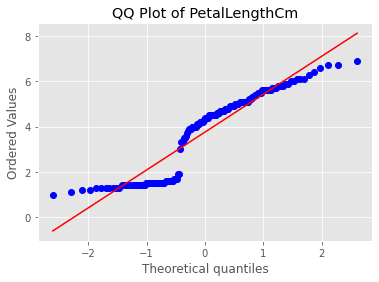

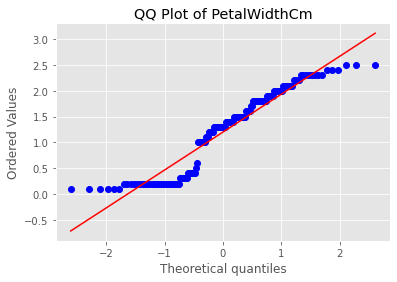

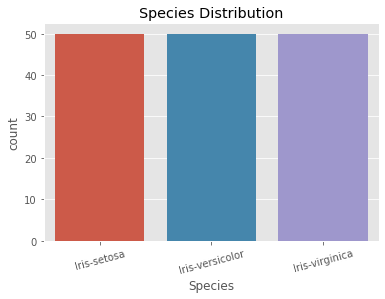


Analysis Completed Successfully!


In [1]:

!pip install pandas numpy scipy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import trim_mean, median_abs_deviation, probplot

plt.style.use('ggplot')


df = pd.read_csv("Iris.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


if "Id" in df.columns:
    df = df.drop("Id", axis=1)


num_df = df.select_dtypes(include=np.number)

print("\nNumerical Columns:")
print(num_df.columns)


print("\n===== Mean =====")
for col in num_df.columns:
    print(f"{col}: {num_df[col].mean()}")

print("\n===== Median =====")
for col in num_df.columns:
    print(f"{col}: {num_df[col].median()}")

print("\n===== Trimmed Mean =====")
for col in num_df.columns:
    print(f"{col}: {trim_mean(num_df[col].dropna(),0.10)}")

print("\n===== Weighted Mean =====")
for col in num_df.columns:
    data=num_df[col].dropna()
    weights=np.arange(1,len(data)+1)
    print(f"{col}: {np.average(data,weights=weights)}")


print("\n===== Range =====")
for col in num_df.columns:
    print(f"{col}: {num_df[col].max()-num_df[col].min()}")

print("\n===== Variance =====")
for col in num_df.columns:
    print(f"{col}: {num_df[col].var()}")

print("\n===== Standard Deviation =====")
for col in num_df.columns:
    print(f"{col}: {num_df[col].std()}")

print("\n===== IQR =====")
for col in num_df.columns:
    Q1=num_df[col].quantile(0.25)
    Q3=num_df[col].quantile(0.75)
    print(f"{col}: {Q3-Q1}")

print("\n===== MAD =====")
for col in num_df.columns:
    print(f"{col}: {median_abs_deviation(num_df[col].dropna())}")


for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col],color="skyblue")
    plt.title(f"Boxplot of {col}")
    plt.show()


for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],bins=20,color="steelblue")
    plt.title(f"Histogram of {col}")
    plt.show()


for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df[col],fill=True,color="green")
    plt.title(f"Density Plot of {col}")
    plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(num_df.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


if "Species" in df.columns:
    sns.pairplot(df,hue="Species")
else:
    sns.pairplot(num_df)

plt.show()


for col in num_df.columns:
    plt.figure(figsize=(6,4))
    probplot(df[col],dist="norm",plot=plt)
    plt.title(f"QQ Plot of {col}")
    plt.show()


if "Species" in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x="Species",data=df)
    plt.title("Species Distribution")
    plt.xticks(rotation=15)
    plt.show()

print("\nAnalysis Completed Successfully!")